<a href="https://colab.research.google.com/github/sonjoy1s/ML/blob/main/Predicting_Road_Accident_Severity_Using_Traffic_Data_For_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install imbalanced-learn -q

# DataSet Link : https://www.kaggle.com/datasets/kundanbedmutha/transportation-and-accident-prediction-dataset?select=Synthetic_Transportation_Dataset_Expanded_v2.csv

In [19]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SMOTE import
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv("/content/Synthetic_Transportation_Dataset_Expanded_v2.csv")
df.head()

,Record_ID,Timestamp,Latitude,Longitude,Road_ID,Vehicle_Count,Avg_Speed(km/h),Vehicle_Type,Traffic_Density,Weather,Visibility(m),Road_Condition,Accident_Occurred,Accident_Severity,Alert_Generated,temperature,humidity
0,1,03-10-2023 09:50,32.004714,76.971961,RD-285,419,90,Mixed,Medium,Fog,5663,Under Maintenance,Yes,Major,Yes,31.24,61.12
1,2,09-06-2019 08:01,10.632732,77.828652,RD-384,232,104,Mixed,Very High,Rain,896,Wet,No,-,No,48.52,33.07
2,3,08-01-2020 01:38,12.258165,88.810189,RD-282,339,100,Bus,Medium,Storm,9369,Under Maintenance,No,-,No,41.96,43.97
3,4,18-10-2022 05:43,34.289950,95.415253,RD-128,74,63,Car,Low,Clear,2510,Slippery,Yes,Fatal,No,37.96,59.52
4,5,29-06-2023 23:11,31.698993,77.675486,RD-49,187,73,Mixed,Low,Storm,3447,Wet,No,-,No,24.68,48.61


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Record_ID          5500 non-null   int64  
 1   Timestamp          5500 non-null   object 
 2   Latitude           5500 non-null   float64
 3   Longitude          5500 non-null   float64
 4   Road_ID            5500 non-null   object 
 5   Vehicle_Count      5500 non-null   int64  
 6   Avg_Speed(km/h)    5500 non-null   int64  
 7   Vehicle_Type       5500 non-null   object 
 8   Traffic_Density    5500 non-null   object 
 9   Weather            5500 non-null   object 
 10  Visibility(m)      5500 non-null   int64  
 11  Road_Condition     5500 non-null   object 
 12  Accident_Occurred  5500 non-null   object 
 13  Accident_Severity  5500 non-null   object 
 14  Alert_Generated    5500 non-null   object 
 15  temperature        5500 non-null   float64
 16  humidity           5500 

In [22]:
df.shape

(5500, 17)

In [23]:
df.columns

Index(['Record_ID', 'Timestamp', 'Latitude', 'Longitude', 'Road_ID',
       'Vehicle_Count', 'Avg_Speed(km/h)', 'Vehicle_Type', 'Traffic_Density',
       'Weather', 'Visibility(m)', 'Road_Condition', 'Accident_Occurred',
       'Accident_Severity', 'Alert_Generated', 'temperature', 'humidity'],
      dtype='object')

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Record_ID,5500.0,2750.500000,1587.857571,1.000000,1375.750000,2750.500000,4125.250000,5500.000000
Latitude,5500.0,22.572905,8.356760,8.000245,15.480326,22.616598,29.930907,36.998251
Longitude,5500.0,82.476797,8.356606,68.007834,75.370574,82.322999,89.738211,96.991006
Vehicle_Count,5500.0,254.092364,141.397428,10.000000,131.000000,255.000000,377.250000,499.000000
Avg_Speed(km/h),5500.0,61.324909,33.207133,5.000000,33.000000,60.000000,90.000000,119.000000
Visibility(m),5500.0,5046.928364,2806.171704,201.000000,2640.000000,5007.000000,7515.000000,9998.000000
temperature,5500.0,34.903933,8.674031,20.000000,27.400000,34.935000,42.382500,49.990000
humidity,5500.0,59.617035,17.155972,30.000000,44.800000,59.510000,74.292500,89.980000


In [25]:
df.nunique()

,0
Record_ID,5500
Timestamp,5495
Latitude,5500
Longitude,5500
Road_ID,500
Vehicle_Count,490
Avg_Speed(km/h),115
Vehicle_Type,5
Traffic_Density,4
Weather,5


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['Accident_Severity'].unique()

array(['Major', '-', 'Fatal', 'Minor'], dtype=object)

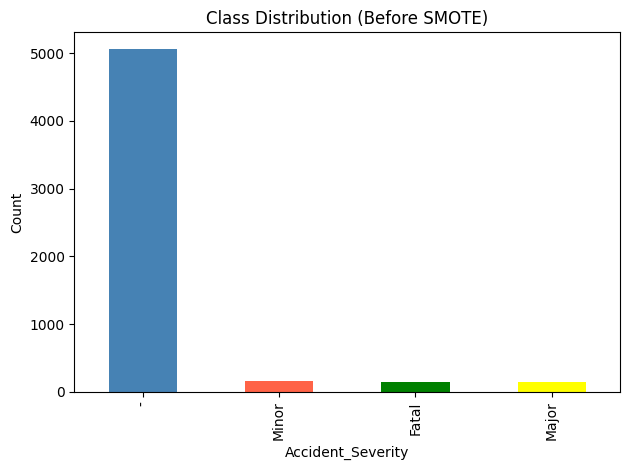

In [28]:
df['Accident_Severity'].value_counts().plot(kind='bar', color=['steelblue','tomato','green','yellow'])
plt.title('Class Distribution (Before SMOTE)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [29]:
df['Accident_Severity'] = df['Accident_Severity'].replace('-', 'No_Atribute')

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Accident_Severity'] = le.fit_transform(
    df['Accident_Severity']
)

print(le.classes_)

['Fatal' 'Major' 'Minor' 'No_Atribute']


In [31]:
df.head()

,Record_ID,Timestamp,Latitude,Longitude,Road_ID,Vehicle_Count,Avg_Speed(km/h),Vehicle_Type,Traffic_Density,Weather,Visibility(m),Road_Condition,Accident_Occurred,Accident_Severity,Alert_Generated,temperature,humidity
0,1,03-10-2023 09:50,32.004714,76.971961,RD-285,419,90,Mixed,Medium,Fog,5663,Under Maintenance,Yes,1,Yes,31.24,61.12
1,2,09-06-2019 08:01,10.632732,77.828652,RD-384,232,104,Mixed,Very High,Rain,896,Wet,No,3,No,48.52,33.07
2,3,08-01-2020 01:38,12.258165,88.810189,RD-282,339,100,Bus,Medium,Storm,9369,Under Maintenance,No,3,No,41.96,43.97
3,4,18-10-2022 05:43,34.289950,95.415253,RD-128,74,63,Car,Low,Clear,2510,Slippery,Yes,0,No,37.96,59.52
4,5,29-06-2023 23:11,31.698993,77.675486,RD-49,187,73,Mixed,Low,Storm,3447,Wet,No,3,No,24.68,48.61


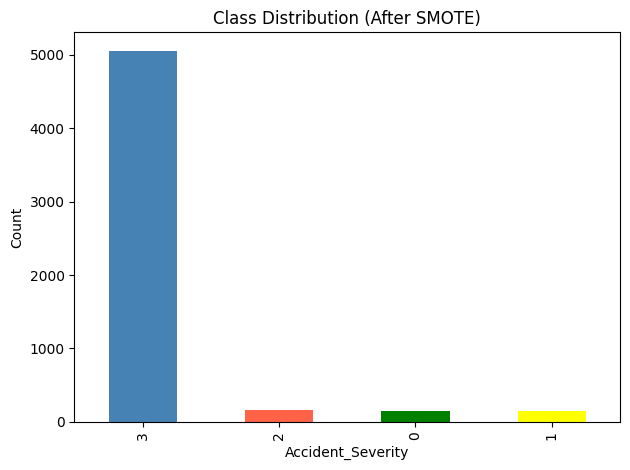

In [32]:
df['Accident_Severity'].value_counts().plot(kind='bar', color=['steelblue','tomato','green','yellow'])
plt.title('Class Distribution (After SMOTE)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [33]:
df.drop(columns=['Record_ID','Timestamp','Road_ID'], axis=1, inplace=True)

In [34]:
df.head()

,Latitude,Longitude,Vehicle_Count,Avg_Speed(km/h),Vehicle_Type,Traffic_Density,Weather,Visibility(m),Road_Condition,Accident_Occurred,Accident_Severity,Alert_Generated,temperature,humidity
0,32.004714,76.971961,419,90,Mixed,Medium,Fog,5663,Under Maintenance,Yes,1,Yes,31.24,61.12
1,10.632732,77.828652,232,104,Mixed,Very High,Rain,896,Wet,No,3,No,48.52,33.07
2,12.258165,88.810189,339,100,Bus,Medium,Storm,9369,Under Maintenance,No,3,No,41.96,43.97
3,34.289950,95.415253,74,63,Car,Low,Clear,2510,Slippery,Yes,0,No,37.96,59.52
4,31.698993,77.675486,187,73,Mixed,Low,Storm,3447,Wet,No,3,No,24.68,48.61


In [35]:
X = df.drop(columns=['Accident_Severity'], axis=1)
y = df['Accident_Severity']

numerical_cols   = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print('Numerical features :', numerical_cols)
print('Categorical features:', categorical_cols)

Numerical features : ['Latitude', 'Longitude', 'Vehicle_Count', 'Avg_Speed(km/h)', 'Visibility(m)', 'temperature', 'humidity']
Categorical features: ['Vehicle_Type', 'Traffic_Density', 'Weather', 'Road_Condition', 'Accident_Occurred', 'Alert_Generated']


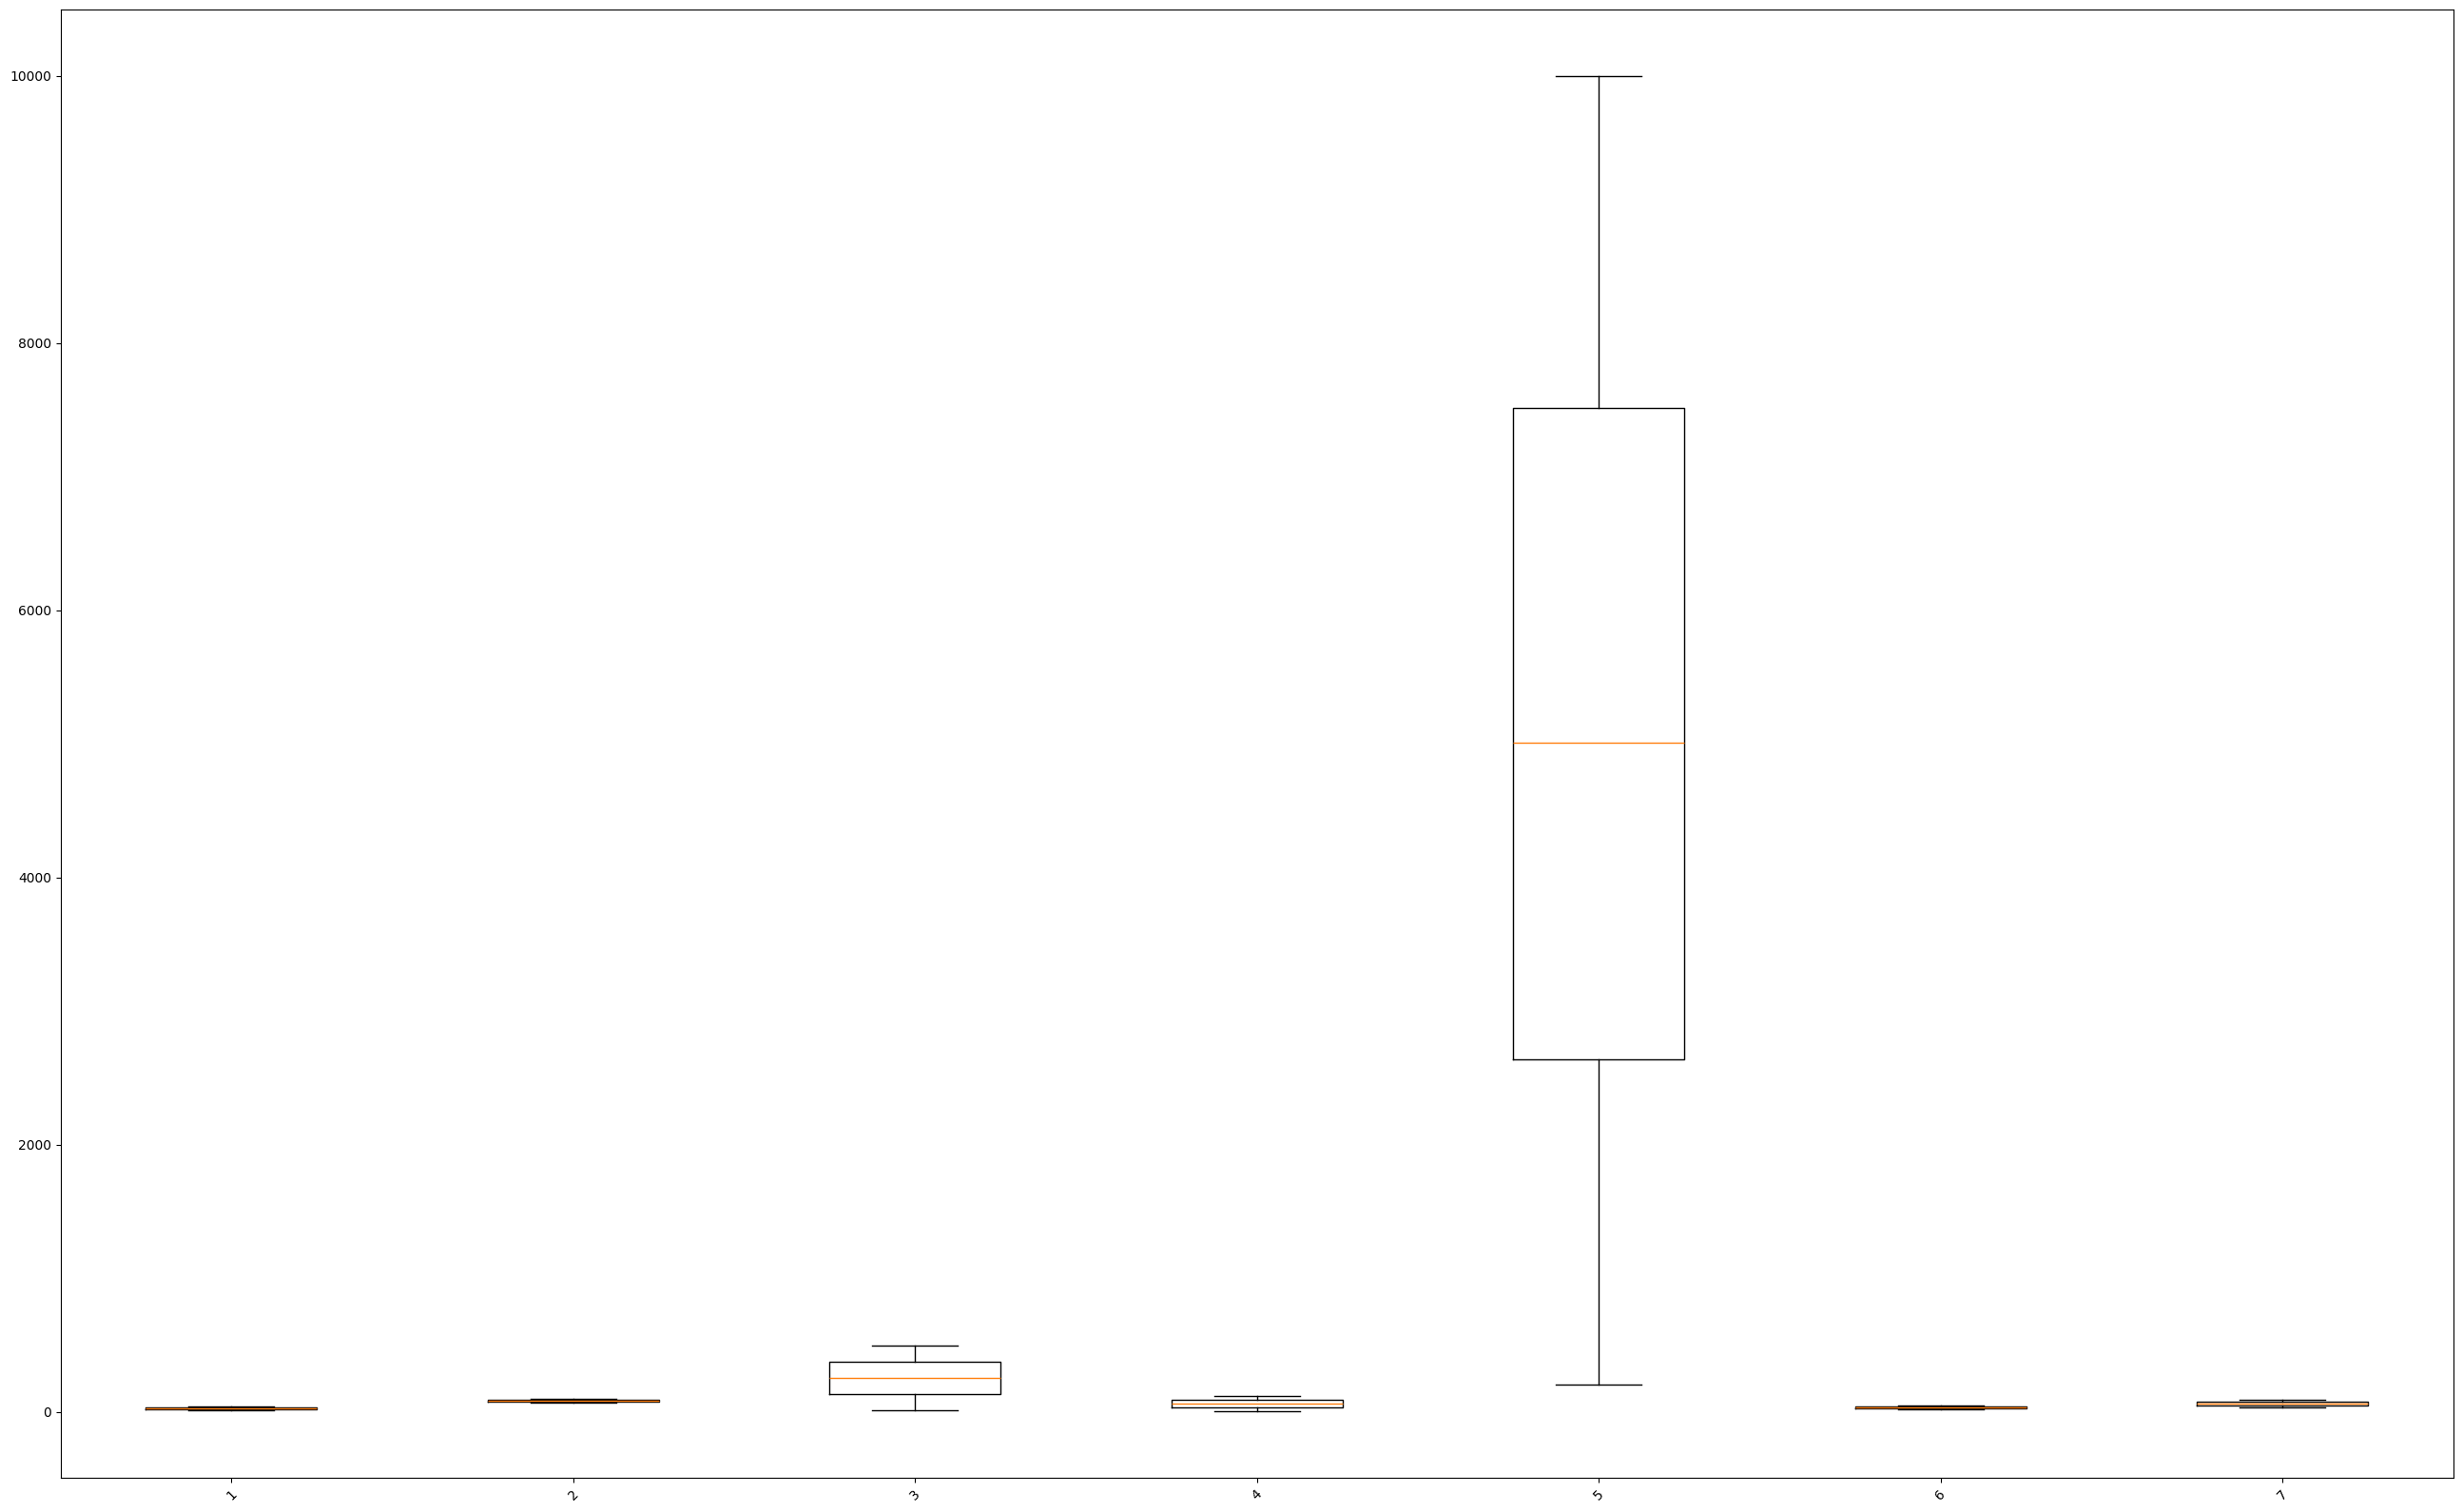

In [36]:
plt.figure(figsize=(26,16))
plt.boxplot(df[numerical_cols])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

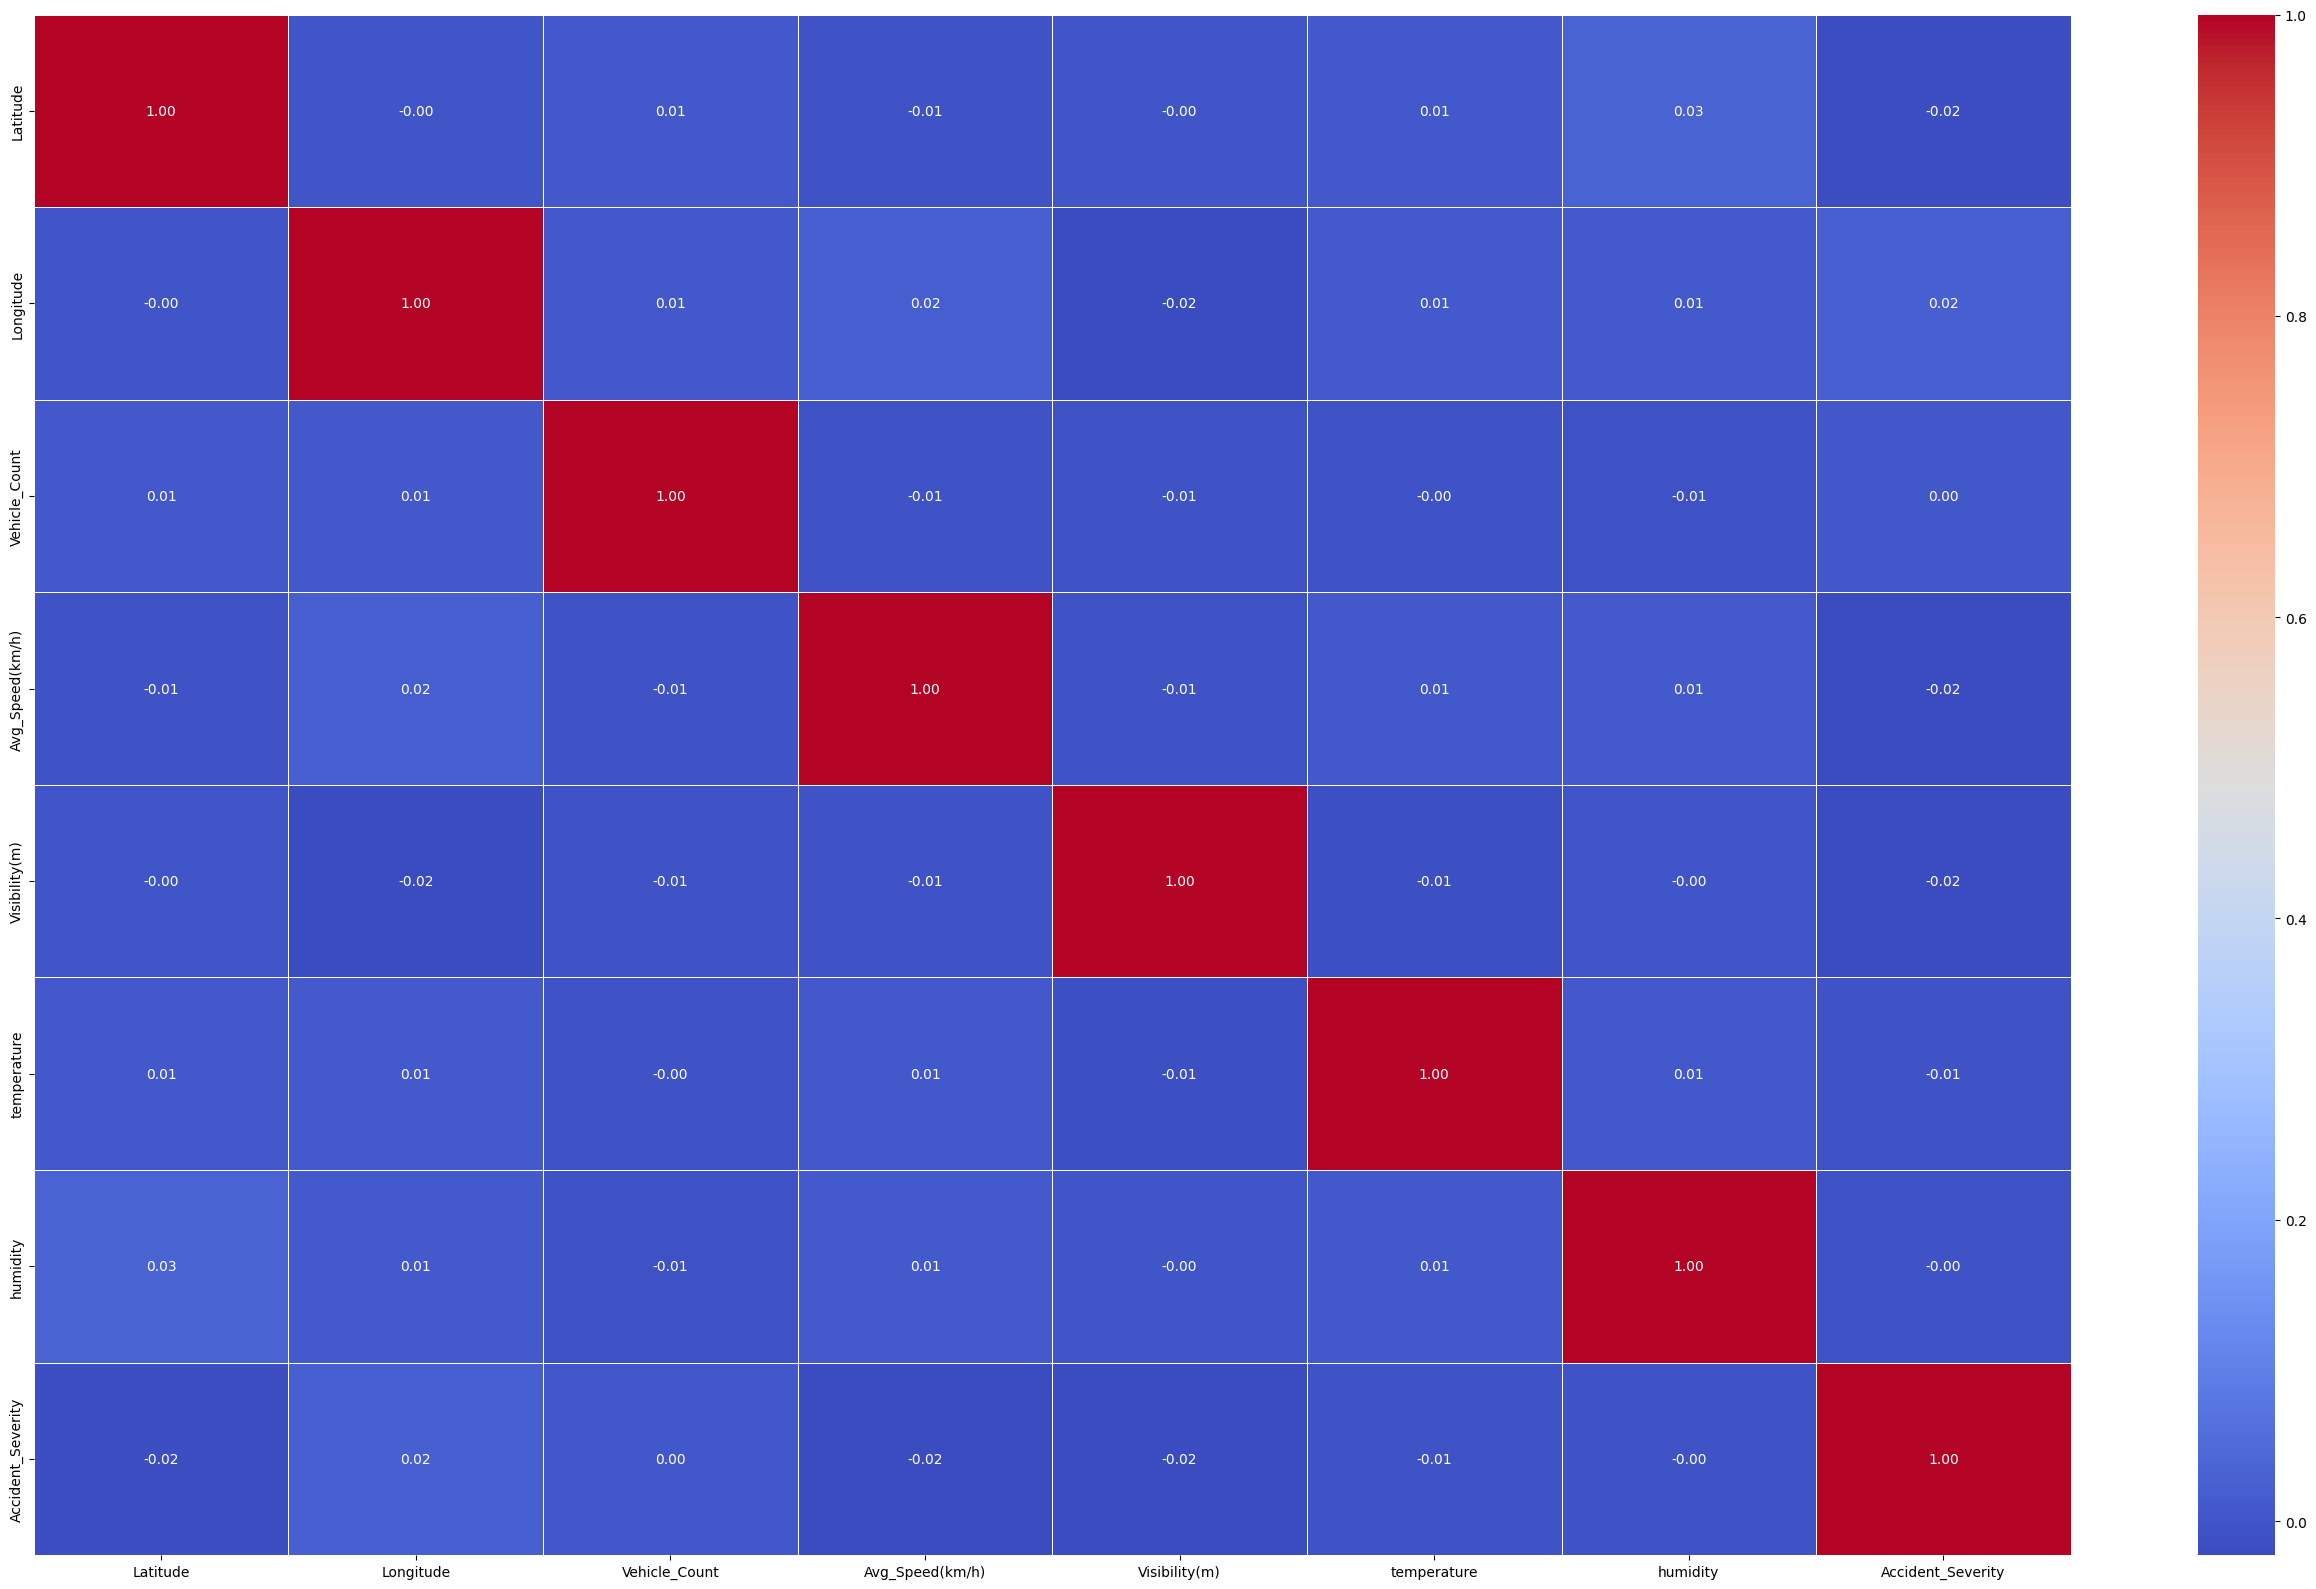

In [37]:
target_col ='Accident_Severity'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.tight_layout()
plt.show()

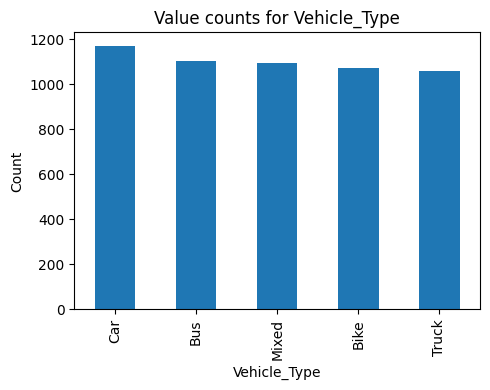

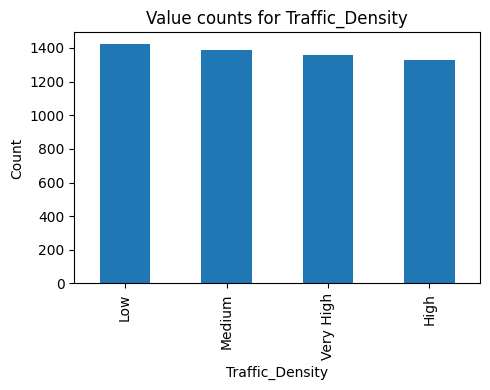

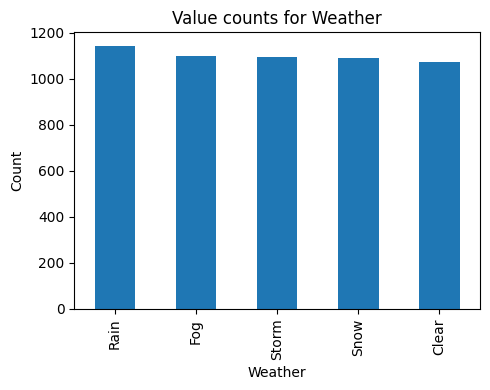

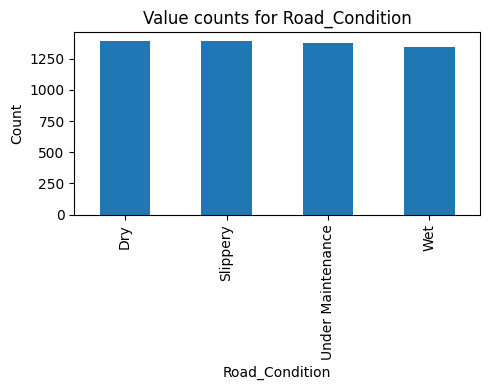

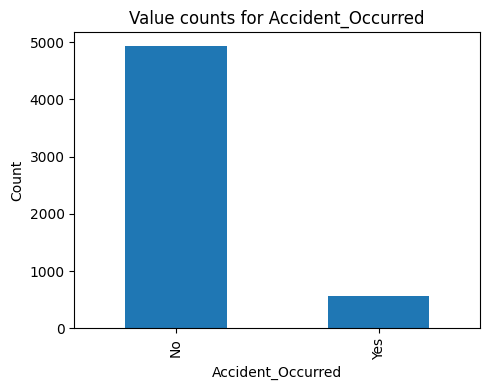

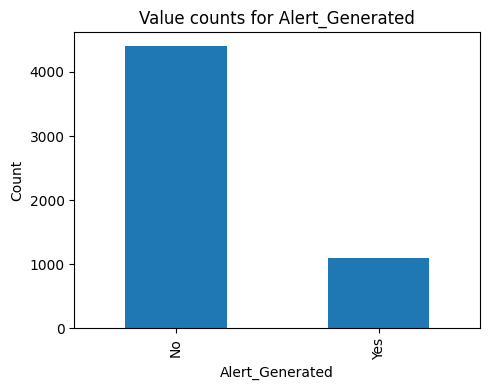

In [38]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (4400, 13)
Test shape : (1100, 13)


In [41]:
import pandas as pd

train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

duplicates = pd.merge(train_df, test_df, how='inner')
print("Duplicate samples:", len(duplicates))

Duplicate samples: 0


In [42]:
numerical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

Combine_pipe = ColumnTransformer([
    ('num', numerical_pipe,   numerical_cols),
    ('cat', categorical_pipe, categorical_cols)
])

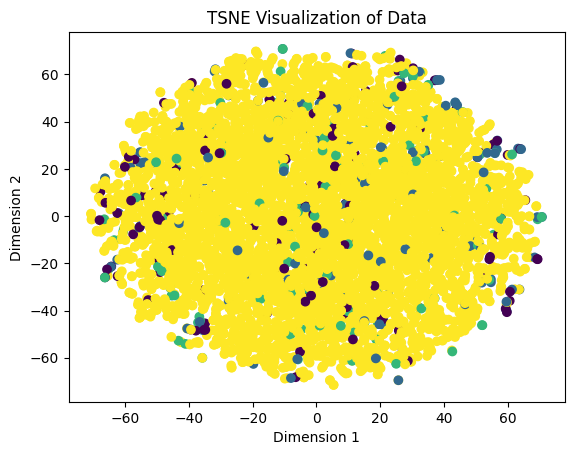

In [59]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_processed = Combine_pipe.fit_transform(X)
X_embedded = TSNE(n_components=2).fit_transform(X_processed[:5000])

plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y[:5000])
plt.title('TSNE Visualization of Data')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [44]:
X_temp = Combine_pipe.fit_transform(X_train)
smote  = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_temp, y_train)

print('SMOTE after class distribution:')
print(pd.Series(y_train).value_counts())
print()
print('SMOTE before class distribution:')
print(pd.Series(y_res).value_counts())

SMOTE after class distribution:
Accident_Severity
3    4045
2     125
0     117
1     113
Name: count, dtype: int64

SMOTE before class distribution:
Accident_Severity
3    4045
0    4045
1    4045
2    4045
Name: count, dtype: int64


In [45]:
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost

lr  = LogisticRegression(C=1.0, penalty='l2', solver='liblinear',
                         max_iter=1000, class_weight='balanced', random_state=42)

sgd = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001,
                    max_iter=1000, class_weight='balanced', random_state=42)

dt  = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                              min_samples_split=5, min_samples_leaf=2,
                              class_weight='balanced', random_state=42)

rf  = RandomForestClassifier(n_estimators=300, max_depth=15,
                              min_samples_split=5, min_samples_leaf=2,
                              max_features='sqrt', class_weight='balanced',
                              random_state=42)

gb  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=5, min_samples_split=5, random_state=42)

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=class_ratio,
                    eval_metric='logloss', random_state=42)

sv  = SVC(C=10, kernel='rbf', gamma='scale', probability=True,
          class_weight='balanced', random_state=42)

voting_cls = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('rf', rf),
                ('gb', gb), ('xgb', xgb), ('sv', sv)],
    voting='soft'
)

stacking_cls = StackingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('rf', rf),
                ('gb', gb), ('xgb', xgb), ('sv', sv)],
    final_estimator=LogisticRegression(class_weight='balanced')
)

print(f'scale_pos_weight = {class_ratio:.2f}')

scale_pos_weight = 1.04


In [46]:
model_to_train = {
    'Logistic Regression' : lr,
    'SGD Classifier'      : sgd,
    'Decision Tree'       : dt,
    'Random Forest'       : rf,
    'Gradient Boosting'   : gb,
    'XGBoost'             : xgb,
    'SVM'                 : sv,
    'Voting Classifier'   : voting_cls,
    'Stacking Classifier' : stacking_cls,
}

results = []

for model_name, model in model_to_train.items():
    print(f'--- Training: {model_name} ---')

    pipe = ImbPipeline(steps=[
        ('combine', Combine_pipe),
        ('smote',   SMOTE(random_state=42)),
        ('model',   model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report   = classification_report(y_test, y_pred)
    cm       = confusion_matrix(y_test, y_pred)

    results.append({
        'model_name' : model_name,
        'accuracy'   : accuracy,
        'report'     : report,
        'cm'         : cm,
        'pipe'       : pipe
    })

    print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(report)
    print(f'Confusion Matrix:\n{cm}\n')

print('\n=== All Model  Summary ===')
for r in sorted(results, key=lambda x: x['accuracy'], reverse=True):
    print(f"{r['model_name']:<25} Accuracy: {r['accuracy']*100:.2f}%")

--- Training: Logistic Regression ---
Accuracy: 0.9309 (93.09%)
              precision    recall  f1-score   support

           0       0.40      0.47      0.43        30
           1       0.26      0.36      0.30        28
           2       0.32      0.39      0.35        31
           3       1.00      0.98      0.99      1011

    accuracy                           0.93      1100
   macro avg       0.49      0.55      0.52      1100
weighted avg       0.95      0.93      0.94      1100

Confusion Matrix:
[[ 14   6  10   0]
 [  8  10  10   0]
 [  9  10  12   0]
 [  4  13   6 988]]

--- Training: SGD Classifier ---
Accuracy: 0.9336 (93.36%)
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        30
           1       0.25      0.43      0.32        28
           2       0.38      0.42      0.40        31
           3       1.00      0.98      0.99      1011

    accuracy                           0.93      1100
   macro avg       0

Best Model: SGD Classifier
   Accuracy  : 93.36%


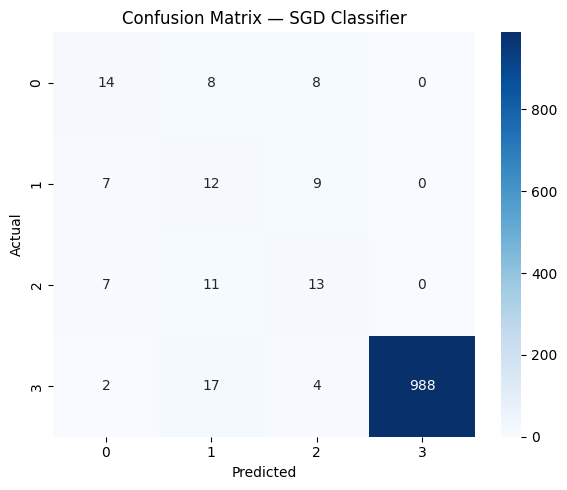

In [47]:
# Best Model
best = max(results, key=lambda x: x['accuracy'])
print(f"Best Model: {best['model_name']}")
print(f"   Accuracy  : {best['accuracy']*100:.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(best['cm'], annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix — {best['model_name']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

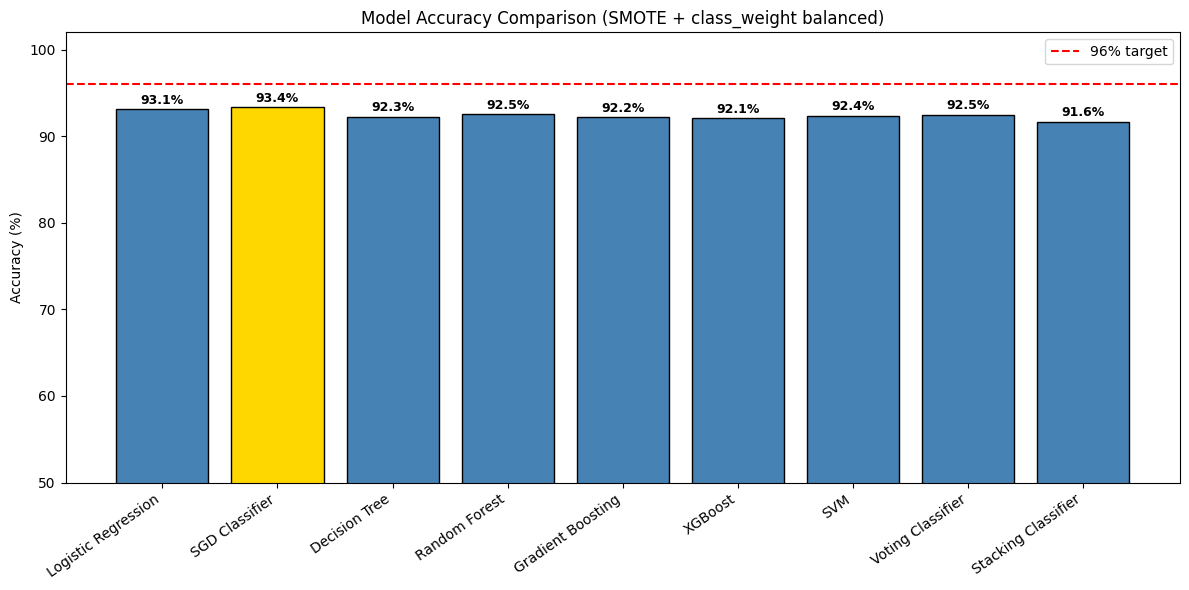

In [48]:
# Accuracy Comparison Bar Chart
model_names = [r['model_name'] for r in results]
accuracies  = [r['accuracy'] * 100 for r in results]

colors = ['gold' if a == max(accuracies) else 'steelblue' for a in accuracies]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')
plt.axhline(y=96, color='red', linestyle='--', label='96% target')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(50, 102)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison (SMOTE + class_weight balanced)')
plt.legend()
plt.tight_layout()
plt.show()

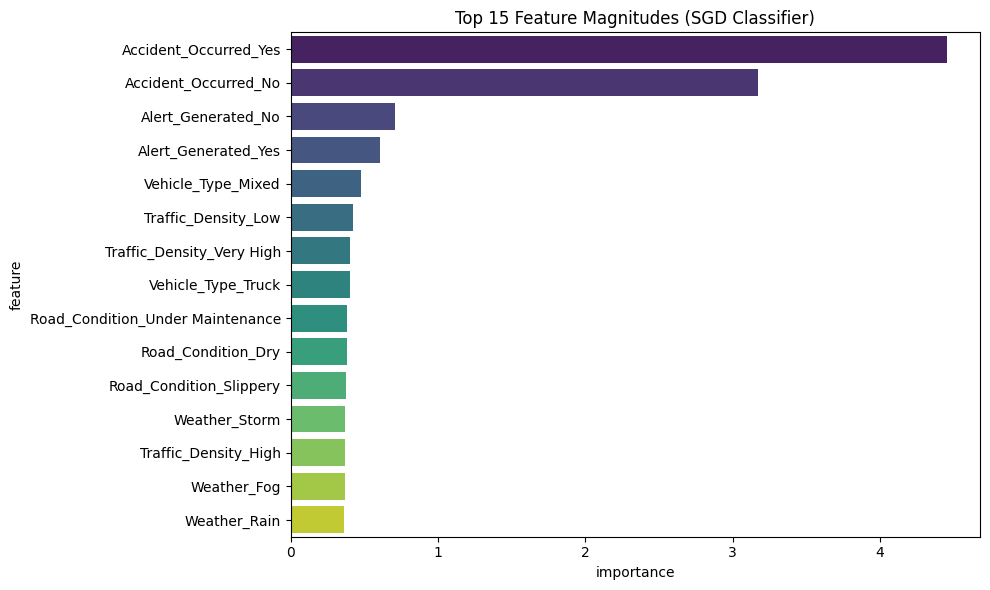

In [49]:
rf_pipe = next(r['pipe'] for r in results if r['model_name'] == 'SGD Classifier')
rf_model = rf_pipe.named_steps['model']

ohe_features = rf_pipe.named_steps['combine'] \
                       .named_transformers_['cat'] \
                       .named_steps['onehot'] \
                       .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

# For SGDClassifier, use coefficients to infer importance
# np.mean(np.abs(rf_model.coef_), axis=0) calculates the mean of absolute coefficients across all classes
importances = np.mean(np.abs(rf_model.coef_), axis=0)
feat_df = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Magnitudes (SGD Classifier)')
plt.tight_layout()
plt.show()

In [50]:
final_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', sgd)
])

final_pipe.fit(X_train, y_train)

y_final_pred = final_pipe.predict(X_test)

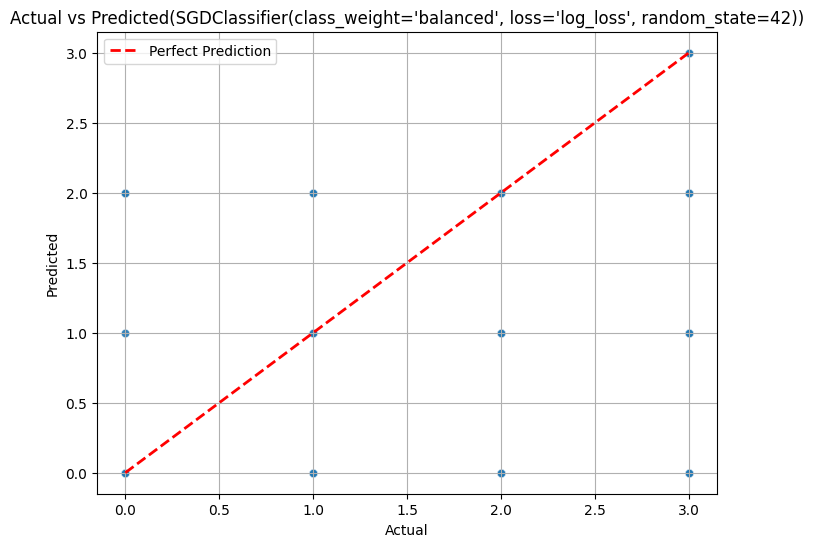

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_final_pred,
    alpha=0.7
)

min_val = min(min(y_test), min(y_final_pred))
max_val = max(max(y_test), max(y_final_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted({sgd})")

plt.legend()
plt.grid(True)



In [52]:
param_grid = {'model__lr__solver': ['lbfgs', 'saga'],
              'model__lr__penalty': ['l2'],
              'model__lr__C': [0.01,0.1,1,10,100],
              'model__lr__max_iter': [1000,5000]
              }

In [53]:
from sklearn.model_selection import GridSearchCV

lg_pipe = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model',sgd)
    ]
)

# Define the parameter grid for GridSearchCV
# The original param_grid was for LogisticRegression, but the model is SGDClassifier.
# Adjusting parameters for SGDClassifier.
param_grid = {
    'model__penalty': ['l1', 'l2', 'elasticnet'], # Valid penalties for SGDClassifier
    'model__alpha': [0.0001, 0.001, 0.01]          # Alpha for regularization
}

grid_search = GridSearchCV(
    estimator=lg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [54]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('combine',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Latitude',
                                                                          'Longitude',
                                                                          'Vehicle_Count',
                                                                          'Avg_Speed(km/h)',
                                                                          'Visibility(m)',
                                                                          'temperature',
                                                                          'humidity']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_f...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Vehicle_Type',
                                                                          'Traffic_Density',
                                                                          'Weather',
                                                                          'Road_Condition',
                                                                          'Accident_Occurred',
                                                                          'Alert_Generated'])])),
                                       ('model',
                                        SGDClassifier(class_weight='balanced',
                                                      loss='log_loss',
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.0001, 0.001, 0.01],
                         'model__penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy', verbose=1)

In [55]:
print("Best Parameters Found:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters Found: {'model__alpha': 0.01, 'model__penalty': 'l1'}
Best CV Accuracy: 0.925909090909091


In [56]:
best_lr_model = grid_search.best_estimator_

In [57]:
y_pred = best_lr_model.predict(X_test)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Final Test Accuracy: 0.9245454545454546
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.17      0.23        30
           1       0.20      0.14      0.17        28
           2       0.25      0.65      0.36        31
           3       1.00      0.98      0.99      1011

    accuracy                           0.92      1100
   macro avg       0.46      0.48      0.44      1100
weighted avg       0.94      0.92      0.93      1100



In [58]:
print('Original numerical columns:', numerical_cols)
print('Original categorical columns:', categorical_cols)

# Get feature names after transformation
feature_names = Combine_pipe.get_feature_names_out()
print('\nTransformed feature names:')
for name in feature_names:
    print(name)

Original numerical columns: ['Latitude', 'Longitude', 'Vehicle_Count', 'Avg_Speed(km/h)', 'Visibility(m)', 'temperature', 'humidity']
Original categorical columns: ['Vehicle_Type', 'Traffic_Density', 'Weather', 'Road_Condition', 'Accident_Occurred', 'Alert_Generated']

Transformed feature names:
num__Latitude
num__Longitude
num__Vehicle_Count
num__Avg_Speed(km/h)
num__Visibility(m)
num__temperature
num__humidity
cat__Vehicle_Type_Bike
cat__Vehicle_Type_Bus
cat__Vehicle_Type_Car
cat__Vehicle_Type_Mixed
cat__Vehicle_Type_Truck
cat__Traffic_Density_High
cat__Traffic_Density_Low
cat__Traffic_Density_Medium
cat__Traffic_Density_Very High
cat__Weather_Clear
cat__Weather_Fog
cat__Weather_Rain
cat__Weather_Snow
cat__Weather_Storm
cat__Road_Condition_Dry
cat__Road_Condition_Slippery
cat__Road_Condition_Under Maintenance
cat__Road_Condition_Wet
cat__Accident_Occurred_No
cat__Accident_Occurred_Yes
cat__Alert_Generated_No
cat__Alert_Generated_Yes


ROC AUC for Class 1: 0.949


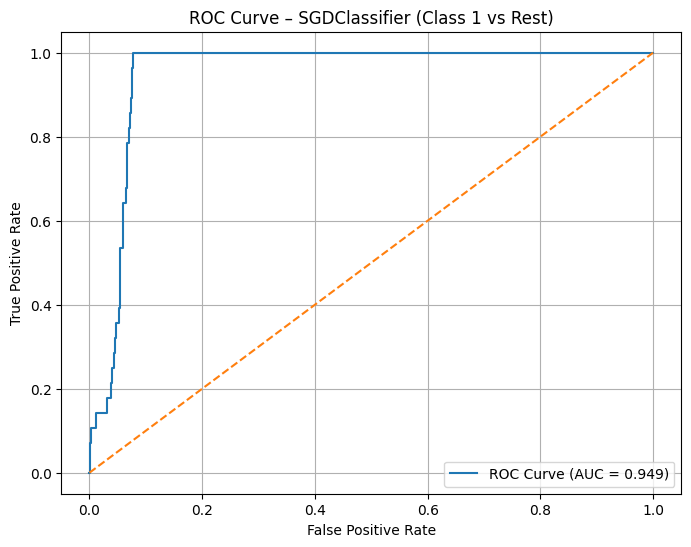

In [61]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for all classes
y_prob_all_classes = best_lr_model.predict_proba(X_test)

# Select probabilities for class 1 (index 1)
y_prob_class_1 = y_prob_all_classes[:, 1]

# Binarize y_test for class 1 (1 if it's class 1, 0 otherwise)
y_test_binary_class_1 = (y_test == 1).astype(int)

# Calculate ROC curve and AUC for class 1
fpr, tpr, _ = roc_curve(y_test_binary_class_1, y_prob_class_1)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC for Class 1: {roc_auc:.3f}")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SGDClassifier (Class 1 vs Rest)")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 698.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7

In [66]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, classification_report

# Set experiment
mlflow.set_experiment("Predicting Road Accident Severity Using Traffic Data")

# Define parameters for LogisticRegression
my_params = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'max_iter': 5000,
    'multi_class': 'multinomial',
    'random_state': 42
}

# Create a LogisticRegression instance with my_params
lr_configured_for_mlflow = LogisticRegression(**my_params)

# Re-define the VotingClassifier to include the configured LogisticRegression
# Use the other base learners (dt, rf, gb, xgb) which are globally defined
sgd_for_mlflow_run = sgd

# pipeline
simple_lr_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', sgd_for_mlflow_run) # Pass the correctly constructed VotingClassifier
])

# Start MLflow run
with mlflow.start_run(run_name="SGD Classifier"):

    mlflow.log_params(my_params)
    mlflow.log_param("model_type", "SGD Classifier")

    # Train model
    simple_lr_pipe.fit(X_train, y_train)
    # Prediction
    y_train_pred = simple_lr_pipe.predict(X_train)
    y_test_pred = simple_lr_pipe.predict(X_test)

    # Evaluate
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    mlflow.log_metric("test_accuracy", test_acc)

    # Log model
    mlflow.sklearn.log_model(simple_lr_pipe, "SGD Classifier",
                             skops_trusted_types=['numpy.dtype', 'sklearn.compose._column_transformer._RemainderColsList'])

    # Print results
    print("Test Accuracy:", test_acc)
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

2026/06/22 18:33:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Test Accuracy: 0.9327272727272727

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.60      0.44        30
           1       0.29      0.21      0.24        28
           2       0.35      0.45      0.39        31
           3       1.00      0.98      0.99      1011

    accuracy                           0.93      1100
   macro avg       0.50      0.56      0.52      1100
weighted avg       0.95      0.93      0.94      1100

